In [16]:
from utils.data import load


data = load(f'/home/burger/bioinfo/project/data/pdb.hdf5')
print('seq:', data[0].shape, type(data[0][0]))
print('node_ss:', data[1].shape, type(data[1][0]))
print('node_rsa:', data[2].shape, type(data[2][0]))
print('node_pos:', data[3].shape, type(data[3][0]))
print('node_idx:', data[4].shape, type(data[4][0]))
print('edge_nho:', data[5].shape, type(data[5][0]))
print('edge_idx:', data[6].shape, type(data[6][0]))
print('lab:', data[7].shape, type(data[7][0]))

seq: (26041138,) <class 'numpy.int32'>
node_ss: (26041138,) <class 'numpy.int32'>
node_rsa: (26041138,) <class 'numpy.float32'>
node_pos: (26041138, 5, 3) <class 'numpy.ndarray'>
node_idx: (106974,) <class 'numpy.int64'>
edge_nho: (2, 18611806) <class 'numpy.ndarray'>
edge_idx: (106974,) <class 'numpy.int64'>
lab: (106973,) <class 'numpy.str_'>


In [34]:
from torch import from_numpy
seqs, node_ss, node_rsa, node_pos, node_idx, edge_nho, edge_idx, lab = data
seq_lens = []

for i in range(len(lab)):
    seq = from_numpy(seqs[node_idx[i]: node_idx[i+1]]) # shape:(len_seq,)
    seq_len = len(seq)
    seq_lens.append(seq_len)

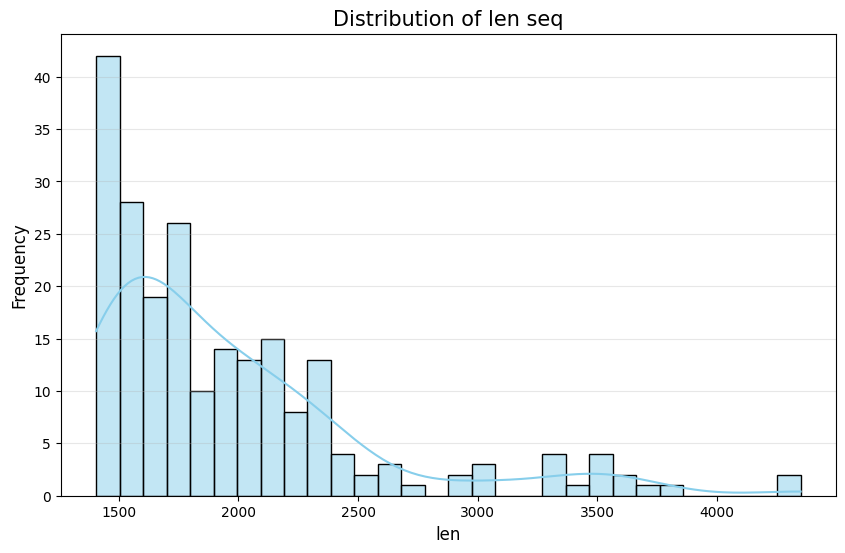

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns


plt.figure(figsize=(10, 6))
seq_lens_1400 = [l for l in seq_lens if l > 1400]
sns.histplot(seq_lens_1400, kde=True, color='skyblue', bins=30)

# 添加装饰
plt.title('Distribution of len seq', fontsize=15)
plt.xlabel('len', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(axis='y', alpha=0.3)

# 显示图表
plt.show()

### 已将数据全部转换为张量

In [41]:
import torch as pt


max_seq_len = 1300
seq_list, lab_list, len_list = [], [], []
for i in range(len(lab)):
    seq = from_numpy(seqs[node_idx[i]: node_idx[i+1]]) # shape:(len_seq,)
    seq_len = len(seq)
    if seq_len <= max_seq_len:
        seq_list.append(seq)
        lab_list.append(lab[i])
        len_list.append(seq_len)
sorted_tuples = sorted(zip(seq_list, lab_list, len_list), key=lambda x: x[2])        
seq_list_sorted = [item[0] for item in sorted_tuples]
lab_list_sorted = [item[1] for item in sorted_tuples]
print(f"Total valid sequences: {len(seq_list_sorted)}")
pt.save((seq_list_sorted, lab_list_sorted), f'./data/seq_shorter_than_{max_seq_len}_sorted.pt')

Total valid sequences: 106663


In [8]:
from torch_geometric.data import Data
import torch as pt
from torch import from_numpy
import torch.nn.functional as F


seqs, node_ss, node_rsa, node_pos, node_idx, edge_nho, edge_idx, lab = data
seq_list, graph_list, lab_list = [], [], []

for i in range(len(lab)):
    seq = from_numpy(seqs[node_idx[i]: node_idx[i+1]]) # shape:(len_seq,)
    ss = from_numpy(node_ss[node_idx[i]: node_idx[i+1]]).long() # shape:(len_seq,)
    rsa = from_numpy(node_rsa[node_idx[i]: node_idx[i+1]]).unsqueeze(-1) # shape:(len_seq,1)
    # shape:(len_seq,8) 0:无定义, 1:α-螺旋, 2:β-折叠, 3:转角, 4:3-10螺旋, 5:π-螺旋, 6:桥联, 7:其他
    ss_onehot = F.one_hot(ss, num_classes=8).float() 
    len_seq = len(seq)
    # shape:(len_seq,5,3) 0:N, 1:α, 2:C, 3:O, 4:β 
    pos = from_numpy(node_pos[node_idx[i]: node_idx[i+1]])
    # N-α-β这个夹角反映了氨基酸的空间结构，在化学键确定的前提下，N和β之间的距离就能反应角度 
    a_b = pt.norm(pos[:, 0] - pos[:, 4], dim=1, keepdim=True)
    node_attr = pt.cat([ss_onehot, rsa, a_b], dim=1) # [num_node, num_node_feature(10)]
    # 连接关系(肽键), 单向
    tai = pt.stack((pt.arange(0, len_seq-1), pt.arange(1, len_seq)), dim=0)
    # 连接关系(氢键), 单向
    nho = pt.stack((from_numpy(edge_nho[0][edge_idx[i] : edge_idx[i+1]]),
                    from_numpy(edge_nho[1][edge_idx[i] : edge_idx[i+1]])), dim=0)
    edge = pt.cat((tai, tai.flip(0), nho, nho.flip(0)), dim=1)
    # 边长 
    # 肽键：羧基碳接氨基氮
    tai_len = pt.norm(pos[tai[0], 2] - pos[tai[1], 0], dim=1)
    nho_len = pt.norm(pos[nho[0], 0] - pos[nho[1], 3], dim=1)
    edge_len = pt.cat((tai_len, tai_len, nho_len, nho_len), dim=0)
    # edge_attr : 键长, is_peptide, direction, is_hbond, 肽键：±1 氢键：0
    is_peptide = pt.cat((pt.ones(tai_len.size(0)*2), pt.zeros(nho_len.size(0)*2)), dim=0)
    is_hbond = 1 - is_peptide
    # 肽键有向氢键无向
    # direction = pt.cat((pt.ones(tai_len.size(0)), -pt.ones(tai_len.size(0)), pt.zeros(nho_len.size(0)*2)), dim=0)
    # 肽键无向氢键有向
    # direction = pt.cat((pt.zeros(tai_len.size(0)*2), pt.ones(nho_len.size(0)), -pt.ones(nho_len.size(0))), dim=0)
    # 肽键氢键都有向
    direction = pt.cat((pt.ones(tai_len.size(0)), -pt.ones(tai_len.size(0)), pt.ones(nho_len.size(0)), -pt.ones(nho_len.size(0))), dim=0)
    edge_attr = pt.stack((edge_len, is_peptide, direction, is_hbond), dim=1) # [num_edge, num_edge_feature]
    # 肽键和氢键都无向
    # edge_attr = pt.stack((edge_len, is_peptide, is_hbond), dim=1) # [num_edge, num_edge_feature]
    
    node2seq = pt.arange(len_seq, dtype=pt.long)
    graph = Data(x=node_attr, edge_index=edge, edge_attr=edge_attr, node2seq=node2seq)
    seq_list.append(seq)
    graph_list.append(graph)
    lab_list.append(lab[i])
pt.save((seq_list, graph_list, lab_list), f'./data/pbond1_hbond1.pt')

In [ ]:
import pandas as pd


df = pd.read_csv('./data/tmalign.out', names=['name1', 'name2', 'tmscore', 'seqid'], delimiter='\t')
df['name1'] = df['name1'].str.split('/').str[-1].str.removesuffix('.pdb')
df['name2'] = df['name2'].str.split('/').str[-1].str.removesuffix('.pdb')
df['remote_homo_score'] = df['tmscore'] - 0.6 + min(0.4 - df['seqid'])

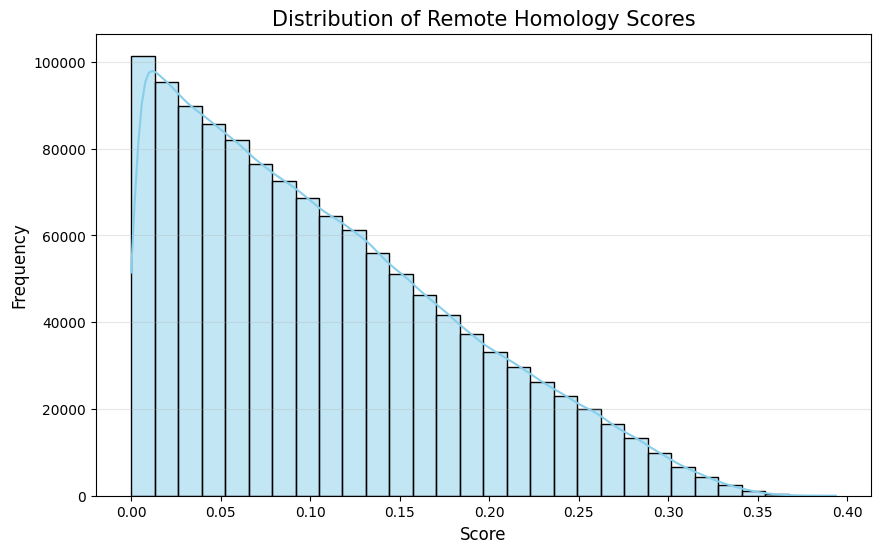

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns


plt.figure(figsize=(10, 6))
sns.histplot(df['remote_homo_score'], kde=True, color='skyblue', bins=30)

# 添加装饰
plt.title('Distribution of Remote Homology Scores', fontsize=15)
plt.xlabel('Score', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(axis='y', alpha=0.3)

# 显示图表
plt.show()